# Final Exam - DS4DS

## General information

This is the problem description for the final project of the course *"Data Science for Dynamical Systems"* (Winter Term 2025/26)
- February 24th or March 10th

Submission before your presentation (via moodle)
- your slides
- your program code

### Grading
For your assessment, we will grade the following parts of your final project
- quality and clarity of the presentation
- your modeling choices and the reasons for your choices
- your approach to data preparation and analysis
- your technical realization (e.g., choice of algorithms, implementation, ...)
- the results as well as their presentation / visualization
- analysis and interpretation of the reseults
- your replies in the consecutive Q&A session

Each participant will be graded invididually, and we expect everyone to participate in the preparation as well as the presentation.

### Tasks
Below, you will find two tasks. One is concerned with data-driven prediction of a large-scale system, the second one with data-driven control of an ODE.

#### IMPORTANT: out of these, you should only select **one** task as your project!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Prediction of reduced PlanetSWE

##### **Dataset:**
* We reduced the PlanetSWE dataset (see https://polymathic-ai.org/the_well/datasets/planetswe/ for details on the original dataset), in the following way:
    * Downsampling of the $256 \times 512$ data images to $128 \times 256$ via mean-pooling.
    * Removing the "height" data-field, such that only the velocity vector field remains. (meaning each time-slice is of shape $2 \times 128 \times 256$)
    * Retaining only the first $1008$ time steps of the original $3024$.
    * Reducing to only $20$ of the $40$ trajectories.
* We have the time scale $(t_0,t_e)=(0,1008)$, with $dt$ of $1$ hour, thus $24$ timesteps for one day and thus $1008/24 = 42$ days.

**Loading**
* The dataset is split into several .zip files, many `train_[...].zip` and one `test_16_19.zip`, containing .npy files.
* **Each .npy file is one entire trajectory!**
* Loading one trajectory, for example the first `X = np.load({path_to_folder}/planetswe_IC00_s1)`, gives you a numpy array of shape `(1008, 2, 128, 256)`.

*Animation of the velocity-magnitude for $200$ time steps, projected onto a sphere:*

![simulation](planetswe_200.gif)

---

#### **Task:**
* **Train a model using this dataset that predicts the system behavior as accurately as possible.**
* You can choose any model presented in the lecture or exercises.

**Initialization**
* As initial condition take the 24th time-step (beginning of day 2, `X[24, :, :, :]`)
* If you decide to use a model with memory, you may use the entire day 1 for initialization, time steps $0$ to $23$: `X[0:24, :, :, :]`

**Train & Test**
* **Only use the trajectories in the `train_[...].zip` for training.**
* Use `test_16_19.zip` for testing.
* The error should be measured as the MSE between the predicted state and the ground truh (i.e., the given data).

---

**Regarding higher computational requirements**
* If you have a CUDA or ROCm capable GPU locally, consider installing PyTorch with the respective compute platform (https://pytorch.org/get-started/locally/)
* You may also use TUDo's LiDO3 cluster (https://lido.itmc.tu-dortmund.de/)
* Otherwise, consider dimensionality reduction techniques, or further downsampling of the data

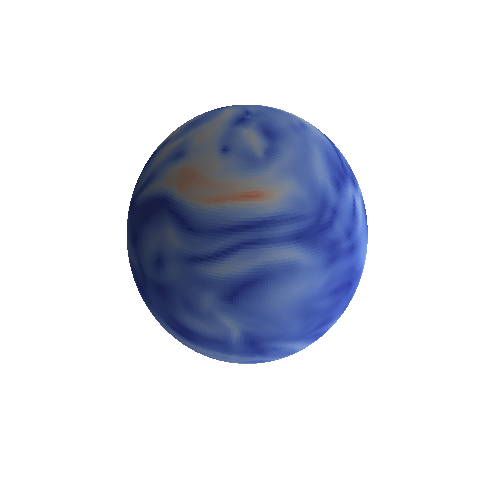

In [2]:
##### EXAMPLE FOR 3D MAPPING #####

velocity = np.load("example_time_step.npy") # equal to X[0] of the trajectory in file planetswe_IC00_s1.npy
# ----------------------------------------------------------------------------------------------------

# Velocity components
v_theta = velocity[0]
v_phi   = velocity[1]

# Define angular grids
n_theta = v_theta.shape[0]
n_phi   = v_theta.shape[1]

theta = np.linspace(np.pi, 0, n_theta)       # polar angle, reverse order!
phi   = np.linspace(0, 2*np.pi, n_phi)       # azimuthal angle

Theta, Phi = np.meshgrid(theta, phi)

# Convert to Cartesian coordinates for plotting the surface
R = np.ones_like(Theta)                      # unit sphere radius
x_coord = R * np.sin(Theta) * np.cos(Phi)
y_coord = R * np.sin(Theta) * np.sin(Phi)
z_coord = R * np.cos(Theta)

# Compute magnitude
speed_mag = np.sqrt(v_theta**2 + v_phi**2).T    # transpose for matching meshgrid orientation

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')

# Plot the colored surface on the sphere
surf = ax.plot_surface(
    x_coord,
    y_coord,
    z_coord,
    facecolors=plt.cm.coolwarm(speed_mag / speed_mag.max()),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False
)

ax.set_box_aspect([1,1,1])
ax.set_axis_off()
plt.show()

Found 16 files in train directory.
Loaded data shape: (16, 1008, 2, 128, 256)
Found 4 files in test directory.
Loaded data shape: (4, 1008, 2, 128, 256)


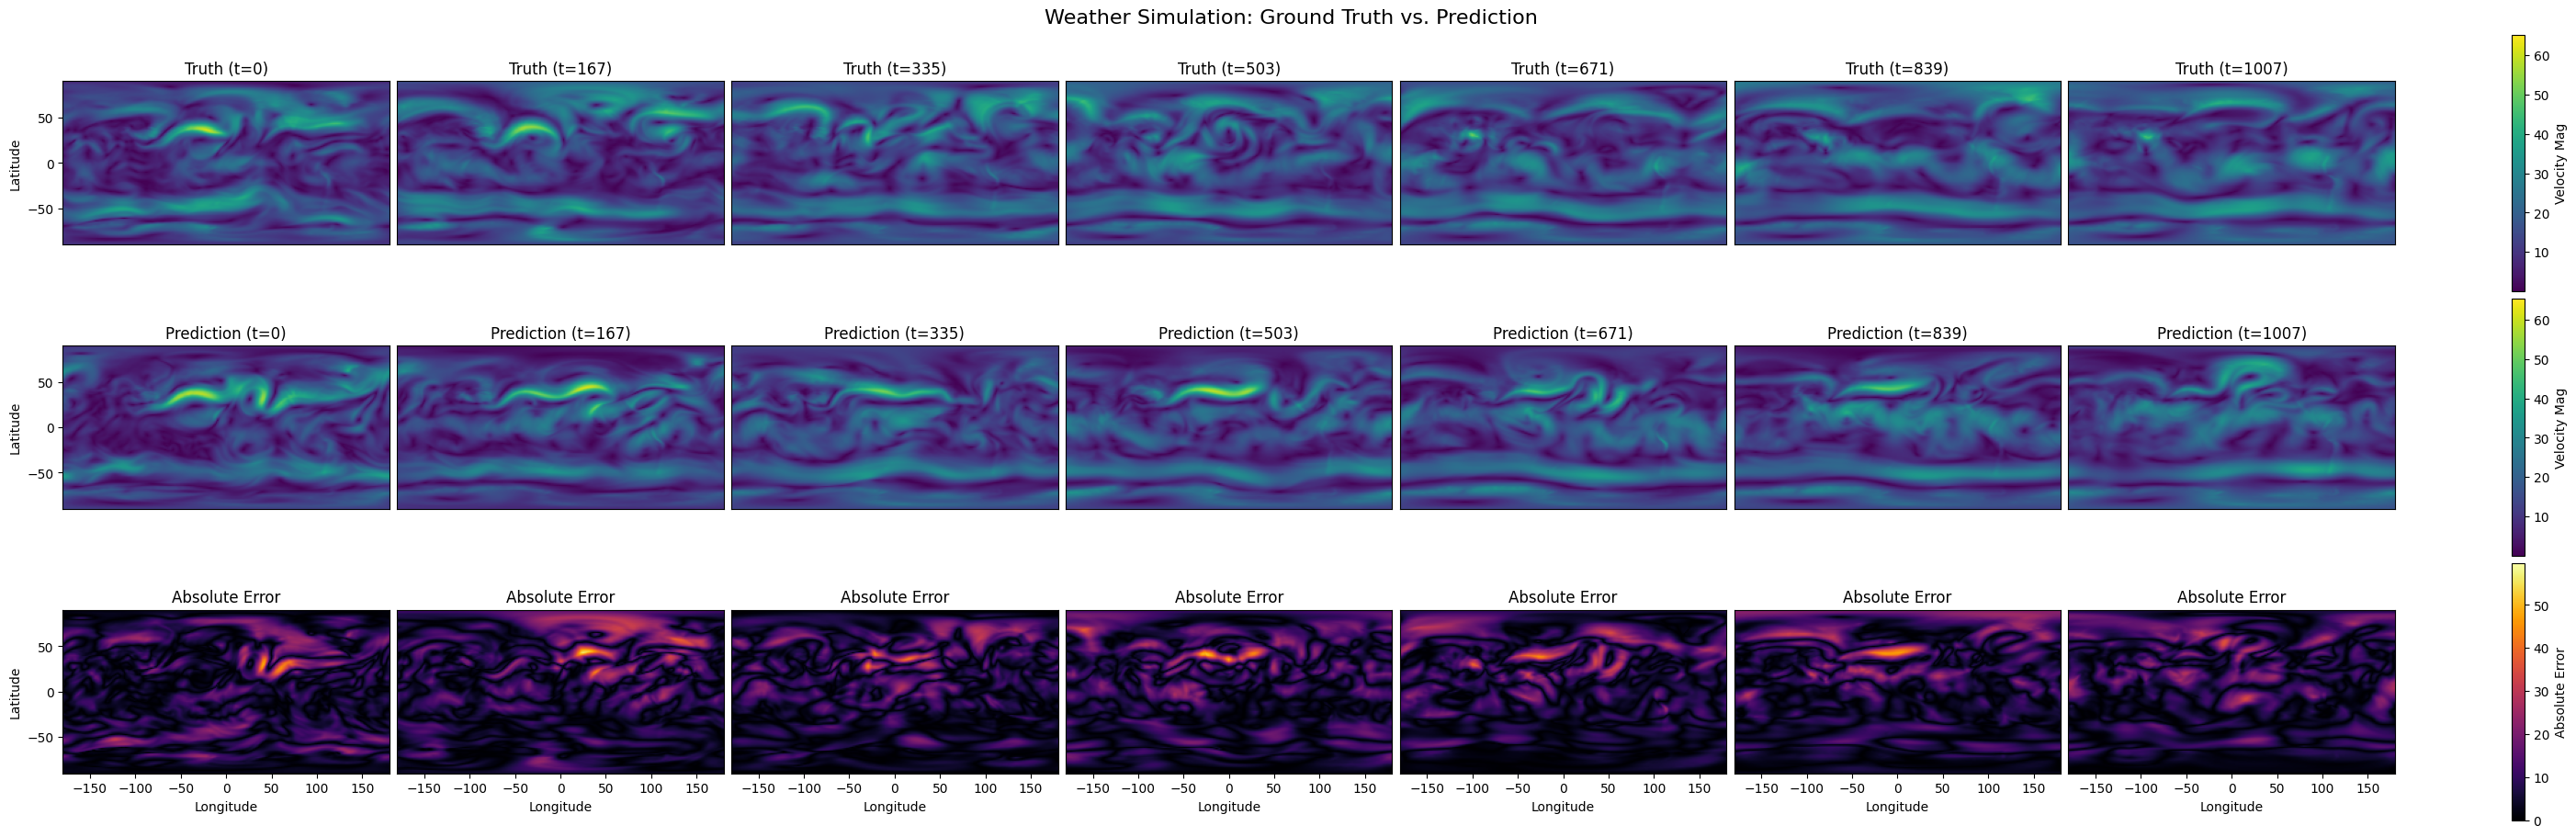

In [3]:
%load_ext autoreload
%autoreload 2
from src.utils import load_data
from src.viz import plot_weather

# Assumes the data sits in a folder called 'data' in the same directory as this notebook
root_dir = "data/"
train_data = load_data(root_dir=root_dir, train=True)[0:1]
test_data = load_data(root_dir=root_dir, train=False)[0:1]

plot_weather(train_data[0], prediction=test_data[0], num_steps=7)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CylindricalPad(nn.Module):
    def __init__(self, padding):
        super().__init__()
        self.p = padding

    def forward(self, x):
        # Pad Longitude circularly, Latitude with zeros
        x = F.pad(x, (self.p, self.p, 0, 0), mode='circular')
        x = F.pad(x, (0, 0, self.p, self.p), mode='constant', value=0)
        return x

class KoopmanAE(nn.Module):
    def __init__(self, latent_channels=16):
        super().__init__()
        
        # --- ENCODER ---
        # 3 simple Conv layers to downsample the grid and extract features
        # Input: (2, 128, 256) -> Output: (latent_channels, 16, 32)
        self.encoder = nn.Sequential(
            CylindricalPad(1), nn.Conv2d(2, 8, kernel_size=4, stride=2, padding=0), nn.ReLU(inplace=True),
            CylindricalPad(1), nn.Conv2d(8, latent_channels, kernel_size=4, stride=2, padding=0), nn.ReLU(inplace=True),
            CylindricalPad(1), nn.Conv2d(latent_channels, latent_channels, kernel_size=4, stride=2, padding=0), nn.ReLU(inplace=True)
        )
        
        # --- KOOPMAN OPERATOR ---
        # A single linear layer to model the dynamics in latent space
        self.koopman_pad = CylindricalPad(1) # Pad latent space for Koopman operator
        self.koopman_operator = nn.Conv2d(latent_channels, latent_channels, kernel_size=3, padding=0, bias=False) # Linear operator in latent space
        
        # --- DECODER ---
        # 3 Upsample layers to reconstruct the original grid
        # Input: (latent_channels, 16, 32) -> Output: (2, 128, 256)
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            CylindricalPad(1), nn.Conv2d(latent_channels, latent_channels, kernel_size=3, padding=0), nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            CylindricalPad(1), nn.Conv2d(latent_channels, 8, kernel_size=3, padding=0), nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            CylindricalPad(1), nn.Conv2d(8, 2, kernel_size=3, padding=0)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x_t):
        # 1. Autoencode current step
        z_t = self.encode(x_t)
        x_recon = self.decode(z_t)
        
        # 2. Predict next step in latent space using the linear operator
        z_next = self.koopman_operator(self.koopman_pad(z_t))
        x_next_pred = self.decode(z_next)
        
        return x_recon, z_t, z_next, x_next_pred
    
# Train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KoopmanAE().to(device)
print(f"Model has {sum(p.numel() for p in model.parameters())} parameters")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

from torch.utils.data import DataLoader, TensorDataset
# Convert numpy data to PyTorch tensors
train_tensor = torch.tensor(train_data.reshape(-1, 2, 128, 256), dtype=torch.float32)
train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_tensor = torch.tensor(test_data.reshape(-1, 2, 128, 256), dtype=torch.float32)
test_dataset = TensorDataset(test_tensor)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

num_epochs = 15
from tqdm import tqdm
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        x_t = batch[0].to(device) # (B, 2, 128, 256)
        
        # Forward pass
        x_recon, z_t, z_next, x_next_pred = model(x_t)
        
        # Compute losses
        recon_loss = nn.MSELoss()(x_recon, x_t)
        pred_loss = nn.MSELoss()(x_next_pred, x_t) # Using current step as proxy for next step
        
        loss = recon_loss + pred_loss
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss recon: {recon_loss.item():.4f}, Loss pred: {pred_loss.item():.4f}, Total Loss: {avg_loss:.4f}")
    
with torch.no_grad():
    model.eval()
    test_loss = 0
    for batch in test_loader:
        x_t = batch[0].to(device)
        x_recon, z_t, z_next, x_next_pred = model(x_t)
        recon_loss = nn.MSELoss()(x_recon, x_t)
        pred_loss = nn.MSELoss()(x_next_pred, x_t)
        loss = recon_loss + pred_loss
        test_loss += loss.item()
    avg_test_loss = test_loss / len(test_loader)
    print(f"Test Loss: {avg_test_loss:.4f}")

Model has 12370 parameters
Epoch 1/15, Loss recon: 145.0505, Loss pred: 146.4377, Total Loss: 294.0663
Epoch 2/15, Loss recon: 113.4686, Loss pred: 117.7611, Total Loss: 262.9574
Epoch 3/15, Loss recon: 65.1618, Loss pred: 76.5595, Total Loss: 176.6203
Epoch 4/15, Loss recon: 34.6990, Loss pred: 54.7948, Total Loss: 107.8256
Epoch 5/15, Loss recon: 21.4941, Loss pred: 30.0400, Total Loss: 63.4018
Epoch 6/15, Loss recon: 15.6574, Loss pred: 20.6390, Total Loss: 42.6530
Epoch 7/15, Loss recon: 12.8812, Loss pred: 18.1329, Total Loss: 34.5564
Epoch 8/15, Loss recon: 11.5083, Loss pred: 16.1678, Total Loss: 29.2905
Epoch 9/15, Loss recon: 10.1076, Loss pred: 14.2338, Total Loss: 25.7847
Epoch 10/15, Loss recon: 9.6001, Loss pred: 13.5420, Total Loss: 23.7600


In [9]:
# Plot example predictions
with torch.no_grad():
    model.eval()
    # Predict the steps from the test set
    test_sample = test_data[0] # (1008, 2, 128, 256)
    # Autoregressive prediction from 24h onwards
    predictions = []
    for t in range(24, 26):
        x_t = torch.tensor(test_sample[t-1:t], dtype=torch.float32, device=device) # (1, 2, 128, 256)
        _, _, _, x_next_pred = model(x_t)
        predictions.append(x_next_pred.cpu().numpy()[0]) # (2, 128, 256)
        
plot_weather(test_sample[25:27], prediction=np.array(predictions), num_steps=3)

ValueError: not enough values to unpack (expected 4, got 1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CylindricalPad(nn.Module):
    """Pads Longitude circularly and Latitude with zeros."""
    def __init__(self, padding):
        super().__init__()
        self.p = padding

    def forward(self, x):
        x = F.pad(x, (self.p, self.p, 0, 0), mode='circular')
        x = F.pad(x, (0, 0, self.p, self.p), mode='constant', value=0)
        return x

class DoubleConv(nn.Module):
    """A standard U-Net block: two convolutions, each followed by BatchNorm and ReLU."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            CylindricalPad(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            CylindricalPad(1),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class MicroUNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=2):
        super().__init__()
        
        # --- ENCODER (Downsampling) ---
        self.inc = DoubleConv(in_channels, 8)
        self.down1 = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(8, 16)
        )
        self.down2 = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(16, 32)
        )
        
        # --- DECODER (Upsampling) ---
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        # Input channels after concatenation: 32 (from up1) + 16 (from skip) = 48
        self.conv_up1 = DoubleConv(48, 16)
        
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        # Input channels after concatenation: 16 (from up2) + 8 (from skip) = 24
        self.conv_up2 = DoubleConv(24, 8)
        
        # --- OUTPUT ---
        self.outc = nn.Conv2d(8, out_channels, kernel_size=1)

    def forward(self, x_t):
        # 1. Encoder passes
        x1 = self.inc(x_t)        # Skip connection 1 (8 channels)
        x2 = self.down1(x1)       # Skip connection 2 (16 channels)
        x3 = self.down2(x2)       # Bottleneck (32 channels)
        
        # 2. Decoder passes with skip connections
        d2 = self.up1(x3)
        # Concatenate bottleneck with skip connection 2 along the channel dimension
        d2 = torch.cat([x2, d2], dim=1) 
        d2 = self.conv_up1(d2)
        
        d1 = self.up2(d2)
        # Concatenate with skip connection 1
        d1 = torch.cat([x1, d1], dim=1) 
        d1 = self.conv_up2(d1)
        
        # 3. Predict the *change* (delta) and add it to the input state
        delta = self.outc(d1)
        x_next_pred = x_t + delta
        
        return x_next_pred
    
# Convert numpy data to PyTorch tensors
X = train_data[:, 0:-1] # (B, 2, 128, 256) - all but last time step
y = train_data[:, 1:]   # (B, 2, 128, 256) - all but first time step
train_tensor = torch.tensor(X.reshape(-1, 2, 128, 256), dtype=torch.float32)
train_labels = torch.tensor(y.reshape(-1, 2, 128, 256), dtype=torch.float32)
train_dataset = TensorDataset(train_tensor, train_labels)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
X_test = test_data[:, 0:-1]
y_test = test_data[:, 1:]
test_tensor = torch.tensor(X_test.reshape(-1, 2, 128, 256), dtype=torch.float32)
test_labels = torch.tensor(y_test.reshape(-1, 2, 128, 256), dtype=torch.float32)
test_dataset = TensorDataset(test_tensor, test_labels)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

model = MicroUNet().to(device)
print(f"Model has {sum(p.numel() for p in model.parameters())} parameters")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
num_epochs = 5
from tqdm import tqdm
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        
        # Forward pass
        pred = model(x)
        
        # Compute losses
        loss = nn.MSELoss()(pred, y) 
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss pred: {pred_loss.item():.4f}")
    
with torch.no_grad():
    model.eval()
    test_loss = 0
    for batch in test_loader:
        x, y = batch.to(device)
        pred = model(x_t)
        pred_loss = nn.MSELoss()(pred, y)
        loss =  pred_loss
        test_loss += loss.item()
    avg_test_loss = test_loss / len(test_loader)
    print(f"Test Loss: {avg_test_loss:.4f}")

Model has 30018 parameters
Epoch 1/5, Loss pred: 8.3980
Epoch 2/5, Loss pred: 8.3980
Epoch 3/5, Loss pred: 8.3980
Epoch 4/5, Loss pred: 8.3980
Epoch 5/5, Loss pred: 8.3980


ValueError: too many values to unpack (expected 2)

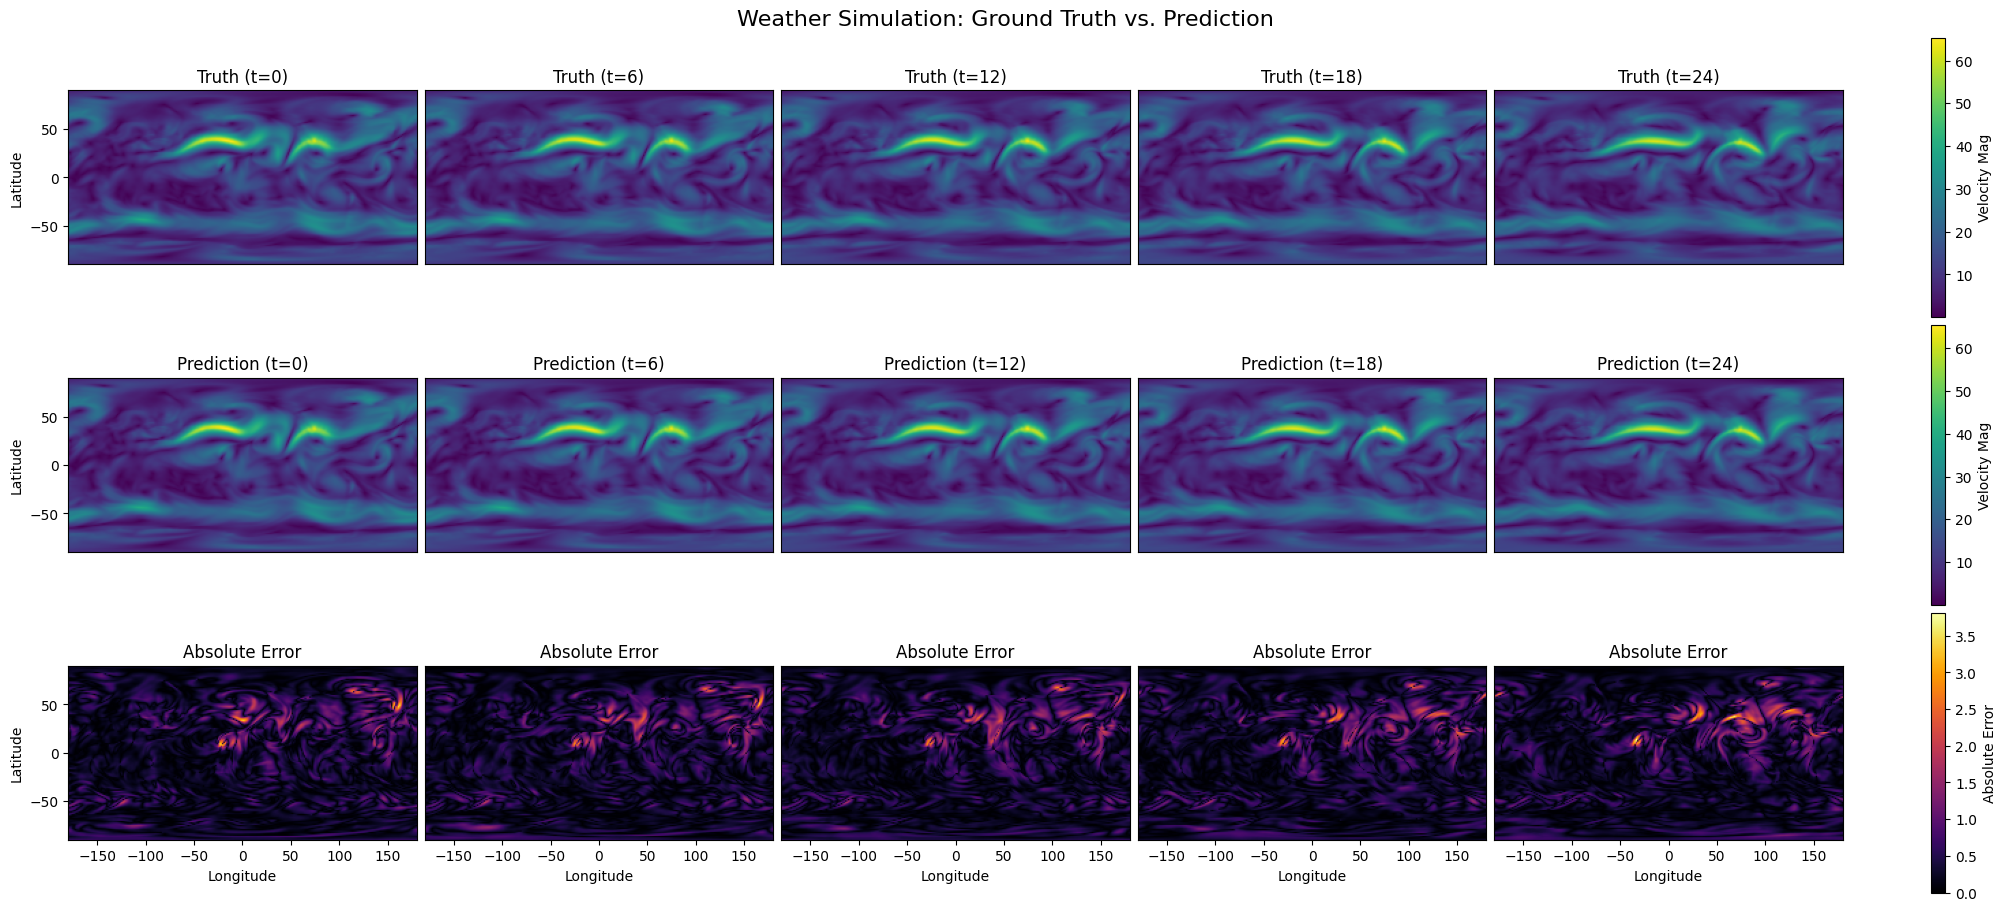

In [8]:
# Plot example predictions
with torch.no_grad():
    model.eval()
    # Predict the steps from the test set
    test_sample = test_data[0] # (1008, 2, 128, 256)
    # Autoregressive prediction from 24h onwards
    predictions = []
    for t in range(24, 49):
        x_t = torch.tensor(test_sample[t-1:t], dtype=torch.float32, device=device) # (1, 2, 128, 256)
        x_next_pred = model(x_t)
        predictions.append(x_next_pred.cpu().numpy()[0]) # (2, 128, 256)
plot_weather(test_sample[25:50], prediction=np.array(predictions), num_steps=5)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TensorizedSpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, rank=16):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.rank = rank

        # --- TUCKER TENSOR DECOMPOSITION ---
        # Instead of a massive weight tensor of size (out, in, modes1, modes2),
        # we learn a small core tensor and projection factors. 
        # This is the primary contribution of the TFNO paper.
        
        # Two cores: One for the low/positive frequencies, one for the high/negative frequencies
        self.core1 = nn.Parameter(torch.randn(rank, rank, rank, rank, dtype=torch.cfloat) / (rank**2))
        self.core2 = nn.Parameter(torch.randn(rank, rank, rank, rank, dtype=torch.cfloat) / (rank**2))
        
        # Factor matrices for Channels and Modes
        self.f_out = nn.Parameter(torch.randn(out_channels, rank, dtype=torch.cfloat) / rank)
        self.f_in  = nn.Parameter(torch.randn(in_channels, rank, dtype=torch.cfloat) / rank)
        self.f_m1  = nn.Parameter(torch.randn(modes1, rank, dtype=torch.cfloat) / rank)
        self.f_m2  = nn.Parameter(torch.randn(modes2, rank, dtype=torch.cfloat) / rank)
        
        # Standard spatial 1x1 convolution for the residual bypass
        self.w_bypass = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        batchsize = x.shape[0]
        
        # 1. Forward 2D Fast Fourier Transform
        # RFFT2 is used because our spatial input is real-valued
        x_ft = torch.fft.rfft2(x)
        
        # 2. Reconstruct the dense weights on the fly from the Tucker Factors
        # W shape: (out_channels, in_channels, modes1, modes2)
        # O = out, I = in, X = modes1, Y = modes2 (capital letters = full size, lowercase = rank)
        W1 = torch.einsum('oixy, Oo, Ii, Xx, Yy -> OIXY', self.core1, self.f_out, self.f_in, self.f_m1, self.f_m2)
        W2 = torch.einsum('oixy, Oo, Ii, Xx, Yy -> OIXY', self.core2, self.f_out, self.f_in, self.f_m1, self.f_m2)
        
        # 3. Apply Spectral Convolution
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        
        # Multiply top-left modes (Positive frequencies)
        out_ft[:, :, :self.modes1, :self.modes2] = torch.einsum(
            'OIXY, bIXY -> bOXY', W1, x_ft[:, :, :self.modes1, :self.modes2])
            
        # Multiply bottom-left modes (Negative frequencies)
        out_ft[:, :, -self.modes1:, :self.modes2] = torch.einsum(
            'OIXY, bIXY -> bOXY', W2, x_ft[:, :, -self.modes1:, :self.modes2])
            
        # 4. Inverse 2D Fast Fourier Transform
        x_spectral = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        
        # 5. Add residual bypass connection
        return x_spectral + self.w_bypass(x)


class TFNO(nn.Module):
    def __init__(self, in_channels=2, out_channels=2, modes1=16, modes2=16, width=32, rank=16):
        super().__init__()
        """
        Args:
            modes1, modes2: The number of Fourier modes to retain. 16 is a good standard.
            width: The number of hidden channels in the latent space.
            rank: The rank of the Tucker Decomposition (lower = fewer parameters).
        """
        self.p_layer = nn.Conv2d(in_channels, width, 1) # Lifting layer
        
        # 4 Stacked Tensorized Fourier Layers
        self.tfno0 = TensorizedSpectralConv2d(width, width, modes1, modes2, rank)
        self.tfno1 = TensorizedSpectralConv2d(width, width, modes1, modes2, rank)
        self.tfno2 = TensorizedSpectralConv2d(width, width, modes1, modes2, rank)
        self.tfno3 = TensorizedSpectralConv2d(width, width, modes1, modes2, rank)
        
        self.q_layer = nn.Sequential(
            nn.Conv2d(width, 64, 1),
            nn.GELU(),
            nn.Conv2d(64, out_channels, 1) # Projection layer
        )

    def forward(self, x):
        # 1. Lift spatial representation to hidden spectral space
        x = self.p_layer(x)
        
        # 2. Spectral convolutions with GELU activations
        x = F.gelu(self.tfno0(x))
        x = F.gelu(self.tfno1(x))
        x = F.gelu(self.tfno2(x))
        x = F.gelu(self.tfno3(x))
        
        # 3. Project back to prediction state
        # Because we're predicting a dynamical system step, we predict the DELTA 
        # (change in state) rather than the raw next state.
        delta = self.q_layer(x)
        
        return delta
    
# Initialize data
trajectory = torch.tensor(train_data, dtype=torch.float32) # (B, T, 2, 128, 256)


# Initialization
model = TFNO(in_channels=2, out_channels=2, modes1=16, modes2=16, width=32, rank=16).cuda()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
print(f"Model has {sum(p.numel() for p in model.parameters())} parameters")

# In your training loop:
optimizer.zero_grad()

# Predict next step
x_t = trajectory[:, t, :, :, :].cuda()      # Current state
x_truth = trajectory[:, t+1, :, :, :].cuda()  # Ground truth next state

delta = model(x_t)
x_pred = x_t + delta # Predict residual change

loss = criterion(x_pred, x_truth)
loss.backward()
optimizer.step()

Model has 536994 parameters
